In [ ]:
# Colab Cell 1: Setup and Imports
# Install necessary library (if not already installed)
# !pip install -q scikit-learn
# The standard libraries are usually pre-installed in Colab

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import History # Used for training logs

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Define hyperparameters/constants
MAX_WORDS = 10000  # Vocabulary size (number of unique words to consider)
MAX_LEN = 250      # Maximum length of all sequences (will be updated later)
EMBEDDING_DIM = 128 # Dimension of the word vectors
LSTM_UNITS = 128   # Number of units in the LSTM layer
DROPOUT_RATE = 0.2
EPOCHS = 10
BATCH_SIZE = 64

print("Setup Complete. Libraries loaded and constants defined.")

Setup Complete. Libraries loaded and constants defined.


In [ ]:
# Colab Cell 2: Load and Inspect IMDb Data

# Load the data - the IMDB dataset is pre-tokenized.
# num_words=MAX_WORDS ensures we only keep the top MAX_WORDS frequent words.
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=MAX_WORDS)

# Combine for initial inspection/analysis
X_data = np.concatenate((X_train_raw, X_test_raw), axis=0)
y_data = np.concatenate((y_train, y_test), axis=0)

print(f"Total number of reviews: {len(X_data)}")
print(f"Training set size: {len(X_train_raw)}")
print(f"Test set size: {len(X_test_raw)}")
print(f"Target labels (0=Negative, 1=Positive):")
print(f"  Negative (0): {np.sum(y_data == 0)}")
print(f"  Positive (1): {np.sum(y_data == 1)}")
print(f"  Imbalance Check: {'Balanced' if np.sum(y_data == 0) == np.sum(y_data == 1) else 'Slightly Imbalanced'}")
# Note: IMDb is usually perfectly balanced (25k pos, 25k neg). No imbalance handling needed.

# --- Inspect Sample Review ---
# Get word index mapping for human readability (Note: indices are offset by 3)
word_index = imdb.get_word_index()
reverse_word_index = dict([(value + 3, key) for (key, value) in word_index.items()])
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>" # Unknown word
reverse_word_index[3] = "<UNUSED>"

def decode_review(sequence):
    return ' '.join([reverse_word_index.get(i, '?') for i in sequence])

print("\nSample Decoded Review (First Training Example):")
print(decode_review(X_train_raw[0]))

# --- Split for Validation ---
# We split the raw training data further into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.2, random_state=42
)

print(f"\nTraining set (after split): {len(X_train)}")
print(f"Validation set: {len(X_val)}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total number of reviews: 50000
Training set size: 25000
Test set size: 25000
Target labels (0=Negative, 1=Positive):
  Negative (0): 25000
  Positive (1): 25000
  Imbalance Check: Balanced
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Sample Decoded Review (First Training Example):
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have

In [ ]:
# Colab Cell 3: Statistical Analysis and Padding

# --- 2.1 Statistical Analysis to find MAX_LEN (from previous explanation) ---
# Calculate the length of each sequence in the full dataset
all_lengths = [len(s) for s in np.concatenate((X_train_raw, X_test_raw), axis=0)]
sequence_lengths = np.array(all_lengths)

# Find the 95th percentile
p95 = np.percentile(sequence_lengths, 95)
MAX_LEN = int(p95)

print(f"95th Percentile Length: {MAX_LEN} tokens.")
print(f"We will set MAX_LEN to: {MAX_LEN}")

# --- 2.2 Padding Sequences ---
# Pad training sequences
X_train_padded = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
# Pad validation sequences
X_val_padded = pad_sequences(X_val, maxlen=MAX_LEN, padding='post', truncating='post')
# Pad test sequences
X_test_padded = pad_sequences(X_test_raw, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nOriginal Training Shape: {len(X_train)}")
print(f"Padded Training Shape: {X_train_padded.shape}")
print(f"Padded Test Shape: {X_test_padded.shape}")

# Note on Tokenizer: Keras IMDB loader already provided integers.
# The vocabulary size (MAX_WORDS) and the mapping (reverse_word_index)
# serve the purpose of the tokenizer for this specific dataset.

95th Percentile Length: 598 tokens.
We will set MAX_LEN to: 598

Original Training Shape: 20000
Padded Training Shape: (20000, 598)
Padded Test Shape: (25000, 598)


In [ ]:
# Colab Cell 4: Build and Train LSTM Model

# 1. Define Sequential Model
model = Sequential([
    # Embedding Layer (Trains Word Embeddings from Scratch)
    Embedding(input_dim=MAX_WORDS,          # Size of vocabulary (MAX_WORDS)
              output_dim=EMBEDDING_DIM,     # Dimension of the embedding vectors (128)
              input_length=MAX_LEN),        # Length of input sequences (MAX_LEN)

    # LSTM Layer
    LSTM(LSTM_UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),

    # Output Layer (Binary Classification: 1 neuron, sigmoid activation)
    Dense(1, activation='sigmoid')
])

# 2. Compile Model
model.compile(optimizer='adam',
              loss='binary_crossentropy', # Appropriate for binary classification (0 or 1)
              metrics=['accuracy'])

# Display the model structure
print("Model Summary:")
model.summary()

# 3. Train Model
print("\nStarting Model Training...")
history = model.fit(
    X_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_padded, y_val),
    verbose=1
)

print("\nTraining Complete.")

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Starting Model Training...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 673s 2s/step - accuracy: 0.5020 - loss: 0.6937 - val_accuracy: 0.5128 - val_loss: 0.6930
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 665s 2s/step - accuracy: 0.5086 - loss: 0.6925 - val_accuracy: 0.5134 - val_loss: 0.6940
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 691s 2s/step - accuracy: 0.5118 - loss: 0.6875 - val_accuracy: 0.5120 - val_loss: 0.7030
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 685s 2s/step - accuracy: 0.5188 - loss: 0.6750 - val_accuracy: 0.4880 - val_loss: 0.7103
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 691s 2s/step - accuracy: 0.5302 - loss: 0.6627 - val_accuracy: 0.5114 - val_loss: 0.7293
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 672s 2s/step - accuracy: 0.5309 - loss: 0.6577 - val_accuracy: 0.5118 - val_loss: 0.7400
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 674s 2s/step - accuracy: 0.5306 - loss: 0.6576 - val_accuracy: 0.4878 - val_loss: 0.7435
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 697s 2s/step - accuracy: 0.52

Evaluating model on test data...
Test Loss: 0.7678
Test Accuracy: 0.5024
782/782 ━━━━━━━━━━━━━━━━━━━━ 189s 241ms/step

--- Classification Report (Evaluation Metrics) ---
              precision    recall  f1-score   support

           0       0.50      0.97      0.66     12500
           1       0.54      0.03      0.06     12500

    accuracy                           0.50     25000
   macro avg       0.52      0.50      0.36     25000
weighted avg       0.52      0.50      0.36     25000

Accuracy: 0.5024
Precision: 0.5383
Recall: 0.0338
F1-score: 0.0635


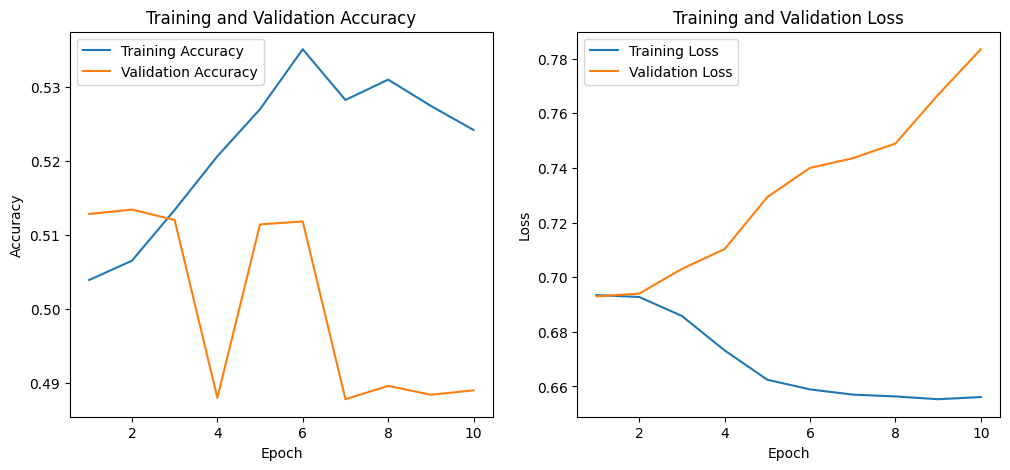

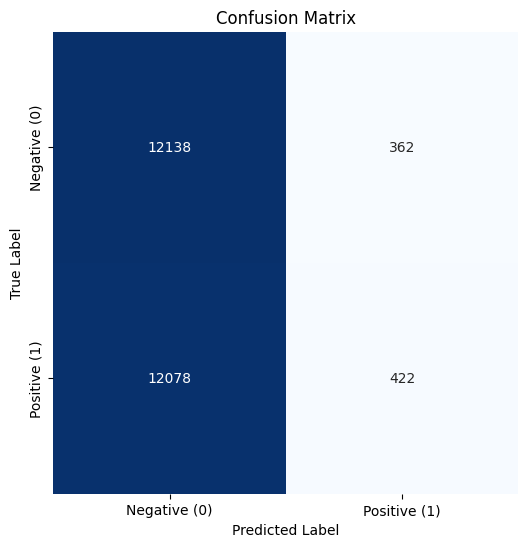


Trained model saved as 'lstm_sentiment_model.h5'


In [ ]:
# Colab Cell 5: Evaluation and Visualization

# --- 4.1 Evaluate Model on Test Data ---
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Generate predictions for classification report
y_pred_proba = model.predict(X_test_padded)
# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
y_pred = (y_pred_proba > 0.5).astype(int)

# --- 4.2 Generate Classification Report and Metrics ---
print("\n--- Classification Report (Evaluation Metrics) ---")
print(classification_report(y_test, y_pred))

# Individual Metrics
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-score: {test_f1:.4f}")

# --- 4.3 Visualization: Training Progress Graphs (Accuracy/Loss Curves) ---
hist = history.history
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, hist['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist['loss'], label='Training Loss')
plt.plot(epochs_range, hist['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- 4.4 Visualization: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- 4.5 Save Trained Model ---
# Save the model to a file
model.save('lstm_sentiment_model.h5')
print("\nTrained model saved as 'lstm_sentiment_model.h5'")

In [ ]:
# Colab Cell 4: Build and Train LSTM Model (Must run this first!)

# 1. Define Sequential Model
model = Sequential([
    # ... Embedding Layer definition ...
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    # ... LSTM Layer definition ...
    LSTM(LSTM_UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
    # ... Dense Layer definition ...
    Dense(1, activation='sigmoid')
])

# 2. Compile Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 3. Train Model
history = model.fit(
    X_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_padded, y_val),
    verbose=1
)
# ...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 683s 2s/step - accuracy: 0.4965 - loss: 0.6939 - val_accuracy: 0.5124 - val_loss: 0.6928
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 677s 2s/step - accuracy: 0.5115 - loss: 0.6951 - val_accuracy: 0.4900 - val_loss: 0.6972
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 665s 2s/step - accuracy: 0.5160 - loss: 0.6909 - val_accuracy: 0.4886 - val_loss: 0.6996
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 648s 2s/step - accuracy: 0.5186 - loss: 0.6914 - val_accuracy: 0.5118 - val_loss: 0.6956
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 708s 2s/step - accuracy: 0.5149 - loss: 0.6854 - val_accuracy: 0.4882 - val_loss: 0.7038
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 685s 2s/step - accuracy: 0.5203 - loss: 0.6752 - val_accuracy: 0.5104 - val_loss: 0.7069
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 676s 2s/step - accuracy: 0.5188 - loss: 0.6713 - val_accuracy: 0.5102 - val_loss: 0.7226
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 663s 2s/step - accuracy: 0.5225 - loss: 0.6622 - val_accu